In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def grover_coin(d):
    """
    Return the d x d Grover diffusion coin.
    """
    if d == 1:
        return np.array([[1.0]], dtype=complex)     # 1x1 matrix for dv=1

    J = np.ones((d, d), dtype=complex)              # matrix of all ones of size dv x dv
    I = np.eye(d, dtype=complex)                    # identity matrix of size dv x dv
    return (2 / d) * J - I                          # Grover coin formula


def check_eulerian(edges):
    """
    Check whether a directed graph is Eulerian.
    edges is a list of tuples: [(u,v), ...]
    """
    indeg = defaultdict(int)                        # in-degree of each vertex with key as source vertex, value as target vertex
    outdeg = defaultdict(int)                       # out-degree of each vertex with key as source vertex, value as target vertex
    vertices = set()                                # set of all vertices in the graph

    for u, v in edges:                              # tuple-unpacking for each edge (u,v) in edges
        outdeg[u] += 1
        indeg[v] += 1
        vertices.add(u)
        vertices.add(v)

    for v in vertices:
        if indeg[v] != outdeg[v]:                   # false, if in-degree and out-degree of any vertex are not equal
            return False

    return True

def build_eulerian_walk_operator(edges):                       
    """
    Build the edge-based Eulerian quantum walk operator U.

    Basis states are directed edges.
    Each incoming edge to a vertex scatters into outgoing edges from that vertex.
    """
    if not check_eulerian(edges):
        raise ValueError("Graph is not Eulerian.")

    edge_to_index = {e: i for i, e in enumerate(edges)}        # i = u, edge_to_index = [0,1,2] for three edges = [(0,1), (1,2), (2,0)]
                                                                # {(0,1) : 0, (1,2) : 1, (2,0): 2}
    n_edges = len(edges) # 3

    incoming = defaultdict(list)
    outgoing = defaultdict(list)

    for e in edges:
        u, v = e
        outgoing[u].append(e) # outgoing[0] = [(0,1)], outgoing[1] = [(1,2)], outgoing[2] = [(2,0)]
        incoming[v].append(e) # incoming[1] = [(0,1)], incoming[2] = [(1,2)], incoming[0] = [(2,0)]

    U = np.zeros((n_edges, n_edges), dtype=complex) # global unitary matrix of size e x e

    vertices = set()
    for u, v in edges:
        vertices.add(u)
        vertices.add(v)     # vertices = {0, 1, 2} 

    for v in vertices:
        in_edges = incoming[v] # incoming[0] = [(2,0)], incoming[1] = [(0,1)], incoming[2] = [(1,2)]
        out_edges = outgoing[v]    # outgoing[0] = [(0,1)], outgoing[1] = [(1,2)], outgoing[2] = [(2,0)]

        d = len(in_edges) # d = 1
        C = grover_coin(d) # make 1x1 matrix of val [1.0]

        for i, e_in in enumerate(in_edges):
            for j, e_out in enumerate(out_edges):
                row = edge_to_index[e_out] # edge_to_index[(0,1)] = 0, edge_to_index[(1,2)] = 1, edge_to_index[(2,0)] = 2
                col = edge_to_index[e_in] # edge_to_index[(2,0)] = 2, edge_to_index[(0,1)] = 0, edge_to_index[(1,2)] = 1
                U[row, col] = C[j, i] # U[0,2] = C[0,0] = 1.0 when v = 0,
                                      # U[1,0] = C[0,0] = 1.0 when v = 1, U[2,1] = C[0,0] = 1.0 when v = 2

    return U, edge_to_index # U = [[0, 0, 1], [1, 0, 0], [0, 1, 0]], edge_to_index = {(0,1): 0, (1,2): 1, (2,0): 2}


def build_walk_operator(edges, coin_type="grover", seed=None):                       
    """
    Build the edge-based Eulerian quantum walk operator U.

    Basis states are directed edges.
    Each incoming edge to a vertex scatters into outgoing edges from that vertex.
    """
    if not check_eulerian(edges):
        raise ValueError("Graph is not Eulerian.")

    edge_to_index = {e: i for i, e in enumerate(edges)}        # i = u, edge_to_index = [0,1,2] for three edges = [(0,1), (1,2), (2,0)]
                                                                # {(0,1) : 0, (1,2) : 1, (2,0): 2}
    n_edges = len(edges) # 3

    incoming = defaultdict(list)
    outgoing = defaultdict(list)

    for e in edges:
        u, v = e
        outgoing[u].append(e) # outgoing[0] = [(0,1)], outgoing[1] = [(1,2)], outgoing[2] = [(2,0)]
        incoming[v].append(e) # incoming[1] = [(0,1)], incoming[2] = [(1,2)], incoming[0] = [(2,0)]

    U = np.zeros((n_edges, n_edges), dtype=complex) # global unitary matrix of size e x e

    vertices = set()
    for u, v in edges:
        vertices.add(u)
        vertices.add(v)     # vertices = {0, 1, 2} 

    for v in vertices:
        in_edges = incoming[v] # incoming[0] = [(2,0)], incoming[1] = [(0,1)], incoming[2] = [(1,2)]
        out_edges = outgoing[v]    # outgoing[0] = [(0,1)], outgoing[1] = [(1,2)], outgoing[2] = [(2,0)]

        d = len(in_edges) # d = 1
        C = grover_coin(d) # make 1x1 matrix of val [1.0]

        for i, e_in in enumerate(in_edges):
            for j, e_out in enumerate(out_edges):
                row = edge_to_index[e_out] # edge_to_index[(0,1)] = 0, edge_to_index[(1,2)] = 1, edge_to_index[(2,0)] = 2
                col = edge_to_index[e_in] # edge_to_index[(2,0)] = 2, edge_to_index[(0,1)] = 0, edge_to_index[(1,2)] = 1
                U[row, col] = C[j, i] # U[0,2] = C[0,0] = 1.0 when v = 0,
                                      # U[1,0] = C[0,0] = 1.0 when v = 1, U[2,1] = C[0,0] = 1.0 when v = 2

    return U, edge_to_index # U = [[0, 0, 1], [1, 0, 0], [0, 1, 0]], edge_to_index = {(0,1): 0, (1,2): 1, (2,0): 2}

edges = [
    (0, 1),
    (1, 2),
    (2, 0),

    (1, 3),
    (3, 4),
    (4, 1)
]

U_grover, edge_to_index = build_walk_operator(edges, coin_type="grover")
U_random, _ = build_walk_operator(edges, coin_type="random", seed=1)

T = 50
start_edge = (0, 1)
start_index = edge_to_index[start_edge]

states_grover = simulate_walk(U_grover, start_index, T)
states_random = simulate_walk(U_random, start_index, T)

probs_grover = np.abs(states_grover) ** 2
probs_random = np.abs(states_random) ** 2

NameError: name 'simulate_walk' is not defined

In [ ]:
U_

NameError: name 'U_' is not defined

In [ ]:
U_grover

array([[0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j]])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def grover_coin(d):
    """
    Return the d x d Grover diffusion coin.
    """
    if d == 1:
        return np.array([[1.0]], dtype=complex)     # 1x1 matrix for dv=1

    J = np.ones((d, d), dtype=complex)              # matrix of all ones of size dv x dv
    I = np.eye(d, dtype=complex)                    # identity matrix of size dv x dv
    return (2 / d) * J - I                          # Grover coin formula

def random_unitary(d):
    """
    Generate a random d x d unitary matrix using QR decomposition.
    """
    Z = np.random.randn(d, d) + 1j * np.random.randn(d, d)
    Q, R = np.linalg.qr(Z)

    diagonal = np.diag(R)
    phases = diagonal / np.abs(diagonal)

    return Q * phases

def check_eulerian(edges):
    """
    Check whether a directed graph is Eulerian.
    edges is a list of tuples: [(u,v), ...]
    """
    indeg = defaultdict(int)                        # in-degree of each vertex with key as source vertex, value as target vertex
    outdeg = defaultdict(int)                       # out-degree of each vertex with key as source vertex, value as target vertex
    vertices = set()                                # set of all vertices in the graph

    for u, v in edges:                              # tuple-unpacking for each edge (u,v) in edges
        outdeg[u] += 1
        indeg[v] += 1
        vertices.add(u)
        vertices.add(v)

    for v in vertices:
        if indeg[v] != outdeg[v]:                   # false, if in-degree and out-degree of any vertex are not equal
            return False

    return True

def build_eulerian_walk_operator(edges):                       
    """
    Build the edge-based Eulerian quantum walk operator U.

    Basis states are directed edges.
    Each incoming edge to a vertex scatters into outgoing edges from that vertex.
    """
    if not check_eulerian(edges):
        raise ValueError("Graph is not Eulerian.")

    edge_to_index = {e: i for i, e in enumerate(edges)}        # i = u, edge_to_index = [0,1,2] for three edges = [(0,1), (1,2), (2,0)]
                                                                # {(0,1) : 0, (1,2) : 1, (2,0): 2}
    n_edges = len(edges) # 3

    incoming = defaultdict(list)
    outgoing = defaultdict(list)

    for e in edges:
        u, v = e
        outgoing[u].append(e) # outgoing[0] = [(0,1)], outgoing[1] = [(1,2)], outgoing[2] = [(2,0)]
        incoming[v].append(e) # incoming[1] = [(0,1)], incoming[2] = [(1,2)], incoming[0] = [(2,0)]

    U = np.zeros((n_edges, n_edges), dtype=complex) # global unitary matrix of size e x e

    vertices = set()
    for u, v in edges:
        vertices.add(u)
        vertices.add(v)     # vertices = {0, 1, 2} 

    for v in vertices:
        in_edges = incoming[v] # incoming[0] = [(2,0)], incoming[1] = [(0,1)], incoming[2] = [(1,2)]
        out_edges = outgoing[v]    # outgoing[0] = [(0,1)], outgoing[1] = [(1,2)], outgoing[2] = [(2,0)]

        d = len(in_edges) # d = 1
        C = grover_coin(d) # make 1x1 matrix of val [1.0]

        for i, e_in in enumerate(in_edges):
            for j, e_out in enumerate(out_edges):
                row = edge_to_index[e_out] # edge_to_index[(0,1)] = 0, edge_to_index[(1,2)] = 1, edge_to_index[(2,0)] = 2
                col = edge_to_index[e_in] # edge_to_index[(2,0)] = 2, edge_to_index[(0,1)] = 0, edge_to_index[(1,2)] = 1
                U[row, col] = C[j, i] # U[0,2] = C[0,0] = 1.0 when v = 0,
                                      # U[1,0] = C[0,0] = 1.0 when v = 1, U[2,1] = C[0,0] = 1.0 when v = 2

    return U, edge_to_index # U = [[0, 0, 1], [1, 0, 0], [0, 1, 0]], edge_to_index = {(0,1): 0, (1,2): 1, (2,0): 2}


def build_walk_operator(edges, coin_type="grover", seed=None):
    if seed is not None:
        np.random.seed(seed)

    if not check_eulerian(edges):
        raise ValueError("Graph is not Eulerian.")

    edge_to_index = {e: i for i, e in enumerate(edges)}
    n_edges = len(edges)

    incoming = defaultdict(list)
    outgoing = defaultdict(list)

    for e in edges:
        u, v = e
        outgoing[u].append(e)
        incoming[v].append(e)

    U = np.zeros((n_edges, n_edges), dtype=complex)

    vertices = set()
    for u, v in edges:
        vertices.add(u)
        vertices.add(v)

    for v in vertices:
        in_edges = incoming[v]
        out_edges = outgoing[v]

        d = len(in_edges)

        if coin_type == "grover":
            C = grover_coin(d)
        elif coin_type == "random":
            C = random_unitary(d)
        else:
            raise ValueError("coin_type must be 'grover' or 'random'.")

        for i, e_in in enumerate(in_edges):
            for j, e_out in enumerate(out_edges):
                row = edge_to_index[e_out]
                col = edge_to_index[e_in]
                U[row, col] = C[j, i]

    return U, edge_to_index

edges = [
    (0, 1),
    (1, 2),
    (2, 0),

    (1, 3),
    (3, 4),
    (4, 1)
]

U_grover, edge_to_index = build_walk_operator(edges, coin_type="grover")
U_random, _ = build_walk_operator(edges, coin_type="random", seed=1)

T = 50
start_edge = (0, 1)
start_index = edge_to_index[start_edge]

states_grover = simulate_walk(U_grover, start_index, T)
states_random = simulate_walk(U_random, start_index, T)

probs_grover = np.abs(states_grover) ** 2
probs_random = np.abs(states_random) ** 2

NameError: name 'simulate_walk' is not defined

In [ ]:
U_random

array([[ 0.        +0.j        ,  0.        +0.j        ,
         0.93583067-0.35244993j,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ],
       [-0.25852132+0.85402339j,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        , -0.1453776 +0.42740628j],
       [ 0.        +0.j        ,  0.57876612-0.81549358j,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ],
       [ 0.4235863 +0.15615831j,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        , -0.82626446-0.33686239j],
       [ 0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        , -0.64297172-0.76588992j,
         0.        +0.j        ,  0.        +0.j        ],
       [ 0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ,
         

In [ ]:
def simulate_walk(U, start_edge_index, T):
    """
    Simulate psi(t+1) = U psi(t).
    """
    n = U.shape[0] # n = 3 for three edges, gives you the number of rows which is the dimension of the Hilbert space which contains one basis state for each edge 

    # |e1> = (1,0,0), |e2> = (0,1,0), |e3> = (0,0,1)
    # hilbert space is spanned by the basis states corresponding to the edges, so n = 3

    psi = np.zeros(n, dtype=complex) # creates a complex 1D array of zeroos off length 3
    psi[start_edge_index] = 1.0 # whatever edge it starts at psi would be of the form either |e1>, |e2>, |e3>

    states = []

    for t in range(T + 1): # T is the no. of time steps
        states.append(psi.copy())
        psi = U @ psi

    return np.array(states)

edges = [
    (0, 1),
    (1, 2),
    (2, 0),

    (1, 3),
    (3, 4),
    (4, 1)
]

In [ ]:
T = 50
start_edge = (0, 1)
start_index = edge_to_index[start_edge]

states_grover = simulate_walk(U_grover, start_index, T)
states_random = simulate_walk(U_random, start_index, T)

probs_grover = np.abs(states_grover) ** 2
probs_random = np.abs(states_random) ** 2

In [ ]:
def long_time_average(probabilities):
    return np.mean(probabilities, axis=0)

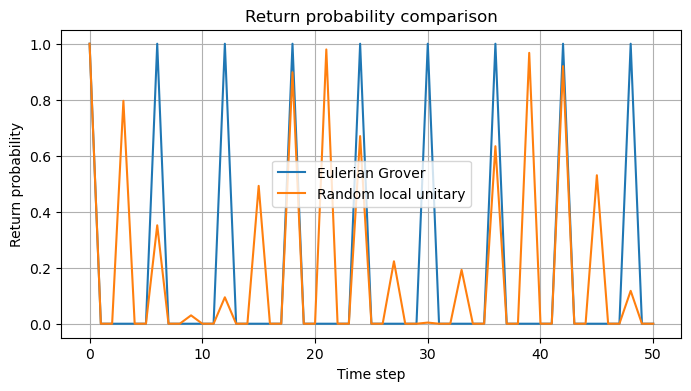

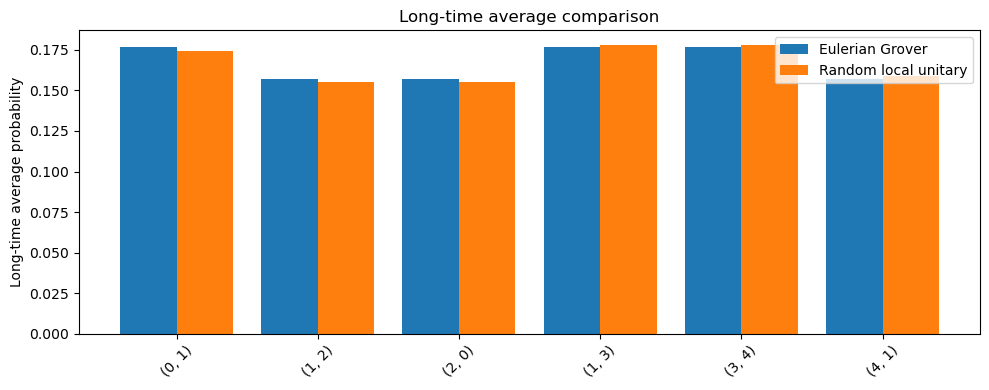

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(probs_grover[:, start_index], label="Eulerian Grover")
plt.plot(probs_random[:, start_index], label="Random local unitary")
plt.xlabel("Time step")
plt.ylabel("Return probability")
plt.title("Return probability comparison")
plt.legend()
plt.grid(True)
plt.show()

avg_grover = long_time_average(probs_grover)
avg_random = long_time_average(probs_random)

labels = [str(e) for e in edges]
x = np.arange(len(edges))

plt.figure(figsize=(10, 4))
plt.bar(x - 0.2, avg_grover, width=0.4, label="Eulerian Grover")
plt.bar(x + 0.2, avg_random, width=0.4, label="Random local unitary")
plt.xticks(x, labels, rotation=45)
plt.ylabel("Long-time average probability")
plt.title("Long-time average comparison")
plt.legend()
plt.tight_layout()
plt.show()

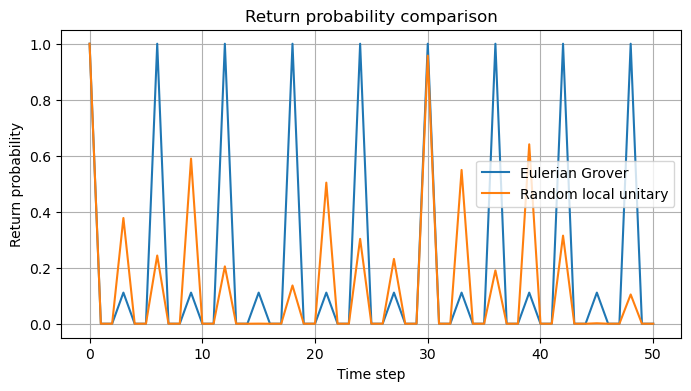

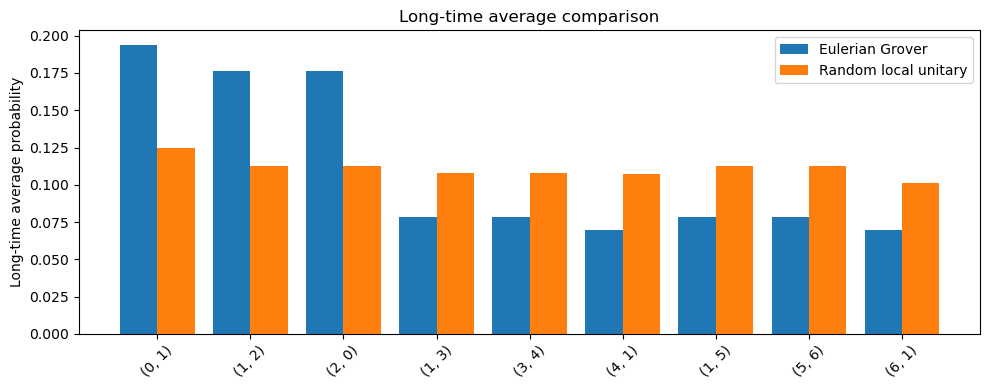

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def grover_coin(d):
    """
    Return the d x d Grover diffusion coin.
    """
    if d == 1:
        return np.array([[1.0]], dtype=complex)     # 1x1 matrix for dv=1

    J = np.ones((d, d), dtype=complex)              # matrix of all ones of size dv x dv
    I = np.eye(d, dtype=complex)                    # identity matrix of size dv x dv
    return (2 / d) * J - I                          # Grover coin formula

def random_unitary(d):
    """
    Generate a random d x d unitary matrix using QR decomposition.
    """
    Z = np.random.randn(d, d) + 1j * np.random.randn(d, d)
    Q, R = np.linalg.qr(Z)

    diagonal = np.diag(R)
    phases = diagonal / np.abs(diagonal)

    return Q * phases

def check_eulerian(edges):
    """
    Check whether a directed graph is Eulerian.
    edges is a list of tuples: [(u,v), ...]
    """
    indeg = defaultdict(int)                        # in-degree of each vertex with key as source vertex, value as target vertex
    outdeg = defaultdict(int)                       # out-degree of each vertex with key as source vertex, value as target vertex
    vertices = set()                                # set of all vertices in the graph

    for u, v in edges:                              # tuple-unpacking for each edge (u,v) in edges
        outdeg[u] += 1
        indeg[v] += 1
        vertices.add(u)
        vertices.add(v)

    for v in vertices:
        if indeg[v] != outdeg[v]:                   # false, if in-degree and out-degree of any vertex are not equal
            return False

    return True

def build_eulerian_walk_operator(edges):                       
    """
    Build the edge-based Eulerian quantum walk operator U.

    Basis states are directed edges.
    Each incoming edge to a vertex scatters into outgoing edges from that vertex.
    """
    if not check_eulerian(edges):
        raise ValueError("Graph is not Eulerian.")

    edge_to_index = {e: i for i, e in enumerate(edges)}        # i = u, edge_to_index = [0,1,2] for three edges = [(0,1), (1,2), (2,0)]
                                                                # {(0,1) : 0, (1,2) : 1, (2,0): 2}
    n_edges = len(edges) # 3

    incoming = defaultdict(list)
    outgoing = defaultdict(list)

    for e in edges:
        u, v = e
        outgoing[u].append(e) # outgoing[0] = [(0,1)], outgoing[1] = [(1,2)], outgoing[2] = [(2,0)]
        incoming[v].append(e) # incoming[1] = [(0,1)], incoming[2] = [(1,2)], incoming[0] = [(2,0)]

    U = np.zeros((n_edges, n_edges), dtype=complex) # global unitary matrix of size e x e

    vertices = set()
    for u, v in edges:
        vertices.add(u)
        vertices.add(v)     # vertices = {0, 1, 2} 

    for v in vertices:
        in_edges = incoming[v] # incoming[0] = [(2,0)], incoming[1] = [(0,1)], incoming[2] = [(1,2)]
        out_edges = outgoing[v]    # outgoing[0] = [(0,1)], outgoing[1] = [(1,2)], outgoing[2] = [(2,0)]

        d = len(in_edges) # d = 1
        C = grover_coin(d) # make 1x1 matrix of val [1.0]

        for i, e_in in enumerate(in_edges):
            for j, e_out in enumerate(out_edges):
                row = edge_to_index[e_out] # edge_to_index[(0,1)] = 0, edge_to_index[(1,2)] = 1, edge_to_index[(2,0)] = 2
                col = edge_to_index[e_in] # edge_to_index[(2,0)] = 2, edge_to_index[(0,1)] = 0, edge_to_index[(1,2)] = 1
                U[row, col] = C[j, i] # U[0,2] = C[0,0] = 1.0 when v = 0,
                                      # U[1,0] = C[0,0] = 1.0 when v = 1, U[2,1] = C[0,0] = 1.0 when v = 2

    return U, edge_to_index # U = [[0, 0, 1], [1, 0, 0], [0, 1, 0]], edge_to_index = {(0,1): 0, (1,2): 1, (2,0): 2}


def build_walk_operator(edges, coin_type="grover", seed=None):
    if seed is not None:
        np.random.seed(seed)

    if not check_eulerian(edges):
        raise ValueError("Graph is not Eulerian.")

    edge_to_index = {e: i for i, e in enumerate(edges)}
    n_edges = len(edges)

    incoming = defaultdict(list)
    outgoing = defaultdict(list)

    for e in edges:
        u, v = e
        outgoing[u].append(e)
        incoming[v].append(e)

    U = np.zeros((n_edges, n_edges), dtype=complex)

    vertices = set()
    for u, v in edges:
        vertices.add(u)
        vertices.add(v)

    for v in vertices:
        in_edges = incoming[v]
        out_edges = outgoing[v]

        d = len(in_edges)

        if coin_type == "grover":
            C = grover_coin(d)
        elif coin_type == "random":
            C = random_unitary(d)
        else:
            raise ValueError("coin_type must be 'grover' or 'random'.")

        for i, e_in in enumerate(in_edges):
            for j, e_out in enumerate(out_edges):
                row = edge_to_index[e_out]
                col = edge_to_index[e_in]
                U[row, col] = C[j, i]

    return U, edge_to_index

def simulate_walk(U, start_edge_index, T):
    """
    Simulate psi(t+1) = U psi(t).
    """
    n = U.shape[0] # n = 3 for three edges, gives you the number of rows which is the dimension of the Hilbert space which contains one basis state for each edge 

    # |e1> = (1,0,0), |e2> = (0,1,0), |e3> = (0,0,1)
    # hilbert space is spanned by the basis states corresponding to the edges, so n = 3

    psi = np.zeros(n, dtype=complex) # creates a complex 1D array of zeroos off length 3
    psi[start_edge_index] = 1.0 # whatever edge it starts at psi would be of the form either |e1>, |e2>, |e3>

    states = []

    for t in range(T + 1): # T is the no. of time steps
        states.append(psi.copy())
        psi = U @ psi

    return np.array(states)

def long_time_average(probabilities):
    return np.mean(probabilities, axis=0)

edges = [
    (0, 1),
    (1, 2),
    (2, 0),

    (1, 3),
    (3, 4),
    (4, 1)
]

edges2 = [
    (0, 1),
    (1, 2),
    (2, 0),

    (1, 3),
    (3, 4),
    (4, 1),

    (1,5),
    (5,6),
    (6,1)
]

U_grover, edge_to_index = build_walk_operator(edges2, coin_type="grover")
U_random, _ = build_walk_operator(edges2, coin_type="random", seed=1)

T = 50
start_edge = (0, 1)
start_index = edge_to_index[start_edge]

states_grover = simulate_walk(U_grover, start_index, T)
states_random = simulate_walk(U_random, start_index, T)

probs_grover = np.abs(states_grover) ** 2
probs_random = np.abs(states_random) ** 2

plt.figure(figsize=(8, 4))
plt.plot(probs_grover[:, start_index], label="Eulerian Grover")
plt.plot(probs_random[:, start_index], label="Random local unitary")
plt.xlabel("Time step")
plt.ylabel("Return probability")
plt.title("Return probability comparison")
plt.legend()
plt.grid(True)
plt.show()

avg_grover = long_time_average(probs_grover)
avg_random = long_time_average(probs_random)

labels = [str(e) for e in edges2]
x = np.arange(len(edges2))

plt.figure(figsize=(10, 4))
plt.bar(x - 0.2, avg_grover, width=0.4, label="Eulerian Grover")
plt.bar(x + 0.2, avg_random, width=0.4, label="Random local unitary")
plt.xticks(x, labels, rotation=45)
plt.ylabel("Long-time average probability")
plt.title("Long-time average comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def grover_coin(d):
    """
    Return the d x d Grover diffusion coin.
    """
    if d == 1:
        return np.array([[1.0]], dtype=complex)     # 1x1 matrix for dv=1

    J = np.ones((d, d), dtype=complex)              # matrix of all ones of size dv x dv
    I = np.eye(d, dtype=complex)                    # identity matrix of size dv x dv
    return (2 / d) * J - I                          # Grover coin formula

def random_unitary(d):
    """
    Generate a random d x d unitary matrix using QR decomposition.
    """
    Z = np.random.randn(d, d) + 1j * np.random.randn(d, d)
    Q, R = np.linalg.qr(Z)

    diagonal = np.diag(R)
    phases = diagonal / np.abs(diagonal)

    return Q * phases

def check_eulerian(edges):
    """
    Check whether a directed graph is Eulerian.
    edges is a list of tuples: [(u,v), ...]
    """
    indeg = defaultdict(int)                        # in-degree of each vertex with key as source vertex, value as target vertex
    outdeg = defaultdict(int)                       # out-degree of each vertex with key as source vertex, value as target vertex
    vertices = set()                                # set of all vertices in the graph

    for u, v in edges:                              # tuple-unpacking for each edge (u,v) in edges
        outdeg[u] += 1
        indeg[v] += 1
        vertices.add(u)
        vertices.add(v)

    for v in vertices:
        if indeg[v] != outdeg[v]:                   # false, if in-degree and out-degree of any vertex are not equal
            return False

    return True

def build_eulerian_walk_operator(edges):                       
    """
    Build the edge-based Eulerian quantum walk operator U.

    Basis states are directed edges.
    Each incoming edge to a vertex scatters into outgoing edges from that vertex.
    """
    if not check_eulerian(edges):
        raise ValueError("Graph is not Eulerian.")

    edge_to_index = {e: i for i, e in enumerate(edges)}        # i = u, edge_to_index = [0,1,2] for three edges = [(0,1), (1,2), (2,0)]
                                                                # {(0,1) : 0, (1,2) : 1, (2,0): 2}
    n_edges = len(edges) # 3

    incoming = defaultdict(list)
    outgoing = defaultdict(list)

    for e in edges:
        u, v = e
        outgoing[u].append(e) # outgoing[0] = [(0,1)], outgoing[1] = [(1,2)], outgoing[2] = [(2,0)]
        incoming[v].append(e) # incoming[1] = [(0,1)], incoming[2] = [(1,2)], incoming[0] = [(2,0)]

    U = np.zeros((n_edges, n_edges), dtype=complex) # global unitary matrix of size e x e

    vertices = set()
    for u, v in edges:
        vertices.add(u)
        vertices.add(v)     # vertices = {0, 1, 2} 

    for v in vertices:
        in_edges = incoming[v] # incoming[0] = [(2,0)], incoming[1] = [(0,1)], incoming[2] = [(1,2)]
        out_edges = outgoing[v]    # outgoing[0] = [(0,1)], outgoing[1] = [(1,2)], outgoing[2] = [(2,0)]

        d = len(in_edges) # d = 1
        C = grover_coin(d) # make 1x1 matrix of val [1.0]

        for i, e_in in enumerate(in_edges):
            for j, e_out in enumerate(out_edges):
                row = edge_to_index[e_out] # edge_to_index[(0,1)] = 0, edge_to_index[(1,2)] = 1, edge_to_index[(2,0)] = 2
                col = edge_to_index[e_in] # edge_to_index[(2,0)] = 2, edge_to_index[(0,1)] = 0, edge_to_index[(1,2)] = 1
                U[row, col] = C[j, i] # U[0,2] = C[0,0] = 1.0 when v = 0,
                                      # U[1,0] = C[0,0] = 1.0 when v = 1, U[2,1] = C[0,0] = 1.0 when v = 2

    return U, edge_to_index # U = [[0, 0, 1], [1, 0, 0], [0, 1, 0]], edge_to_index = {(0,1): 0, (1,2): 1, (2,0): 2}


def build_walk_operator(edges, coin_type="grover", seed=None):
    if seed is not None:
        np.random.seed(seed)

    if not check_eulerian(edges):
        raise ValueError("Graph is not Eulerian.")

    edge_to_index = {e: i for i, e in enumerate(edges)}
    n_edges = len(edges)

    incoming = defaultdict(list)
    outgoing = defaultdict(list)

    for e in edges:
        u, v = e
        outgoing[u].append(e)
        incoming[v].append(e)

    U = np.zeros((n_edges, n_edges), dtype=complex)

    vertices = set()
    for u, v in edges:
        vertices.add(u)
        vertices.add(v)

    for v in vertices:
        in_edges = incoming[v]
        out_edges = outgoing[v]

        d = len(in_edges)

        if coin_type == "grover":
            C = grover_coin(d)
        elif coin_type == "random":
            C = random_unitary(d)
        else:
            raise ValueError("coin_type must be 'grover' or 'random'.")

        for i, e_in in enumerate(in_edges):
            for j, e_out in enumerate(out_edges):
                row = edge_to_index[e_out]
                col = edge_to_index[e_in]
                U[row, col] = C[j, i]

    return U, edge_to_index

def simulate_walk(U, start_edge_index, T):
    """
    Simulate psi(t+1) = U psi(t).
    """
    n = U.shape[0] # n = 3 for three edges, gives you the number of rows which is the dimension of the Hilbert space which contains one basis state for each edge 

    # |e1> = (1,0,0), |e2> = (0,1,0), |e3> = (0,0,1)
    # hilbert space is spanned by the basis states corresponding to the edges, so n = 3

    psi = np.zeros(n, dtype=complex) # creates a complex 1D array of zeroos off length 3
    psi[start_edge_index] = 1.0 # whatever edge it starts at psi would be of the form either |e1>, |e2>, |e3>

    states = []

    for t in range(T + 1): # T is the no. of time steps
        states.append(psi.copy())
        psi = U @ psi

    return np.array(states)

def long_time_average(probabilities):
    return np.mean(probabilities, axis=0)

edges = [
    (0, 1),
    (1, 2),
    (2, 0),

    (1, 3),
    (3, 4),
    (4, 1)
]

edges2 = [
    (0, 1),
    (1, 2),
    (2, 0),

    (1, 3),
    (3, 4),
    (4, 1),

    (1,5),
    (5,6),
    (6,1)
]

edges3 = [
    (0, 1),
    (1, 2),
    (2, 0),

    (1, 3),
    (3, 4),
    (4, 1),

    (1,5),
    (5,6),
    (6,1)

    (0,7),
    (7,0),
    (7,2),
    (2,8),
    (8,7)
]

U_grover, edge_to_index = build_walk_operator(edges3, coin_type="grover")
U_random, _ = build_walk_operator(edges3, coin_type="random", seed=1)

T = 50
start_edge = (0, 1)
start_index = edge_to_index[start_edge]

states_grover = simulate_walk(U_grover, start_index, T)
states_random = simulate_walk(U_random, start_index, T)

probs_grover = np.abs(states_grover) ** 2
probs_random = np.abs(states_random) ** 2

plt.figure(figsize=(8, 4))
plt.plot(probs_grover[:, start_index], label="Eulerian Grover")
plt.plot(probs_random[:, start_index], label="Random local unitary")
plt.xlabel("Time step")
plt.ylabel("Return probability")
plt.title("Return probability comparison")
plt.legend()
plt.grid(True)
plt.show()

avg_grover = long_time_average(probs_grover)
avg_random = long_time_average(probs_random)

labels = [str(e) for e in edges3]
x = np.arange(len(edges3))

plt.figure(figsize=(10, 4))
plt.bar(x - 0.2, avg_grover, width=0.4, label="Eulerian Grover")
plt.bar(x + 0.2, avg_random, width=0.4, label="Random local unitary")
plt.xticks(x, labels, rotation=45)
plt.ylabel("Long-time average probability")
plt.title("Long-time average comparison")
plt.legend()
plt.tight_layout()
plt.show()

<>:199: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
<>:199: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
<ipython-input-11-1248aa69d0b4>:199: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  (6,1)


TypeError: 'tuple' object is not callable

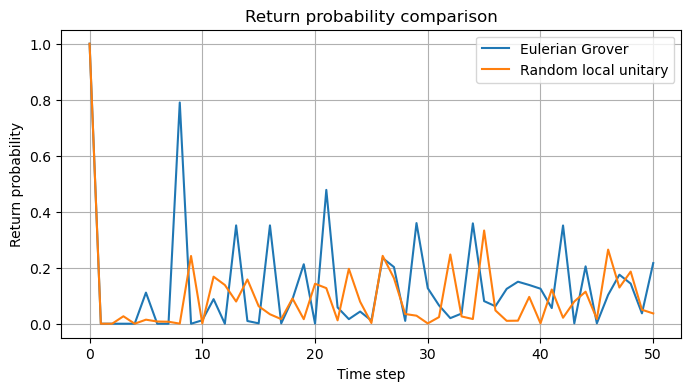

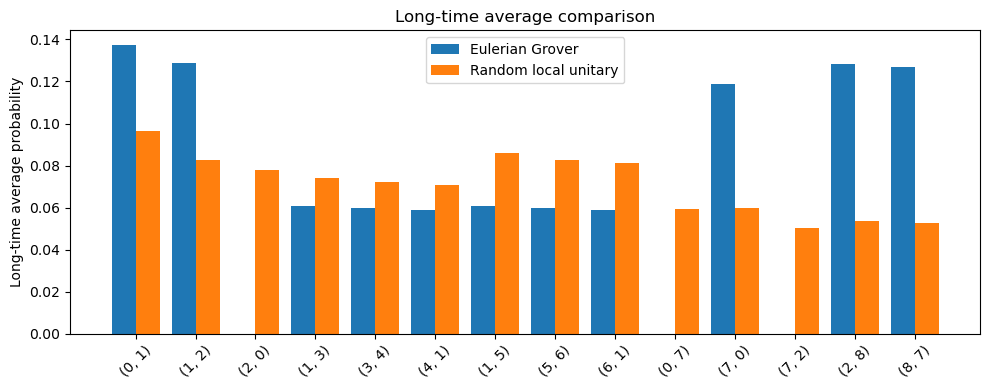

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def grover_coin(d):
    """
    Return the d x d Grover diffusion coin.
    """
    if d == 1:
        return np.array([[1.0]], dtype=complex)     # 1x1 matrix for dv=1

    J = np.ones((d, d), dtype=complex)              # matrix of all ones of size dv x dv
    I = np.eye(d, dtype=complex)                    # identity matrix of size dv x dv
    return (2 / d) * J - I                          # Grover coin formula

def random_unitary(d):
    """
    Generate a random d x d unitary matrix using QR decomposition.
    """
    Z = np.random.randn(d, d) + 1j * np.random.randn(d, d)
    Q, R = np.linalg.qr(Z)

    diagonal = np.diag(R)
    phases = diagonal / np.abs(diagonal)

    return Q * phases

def check_eulerian(edges):
    """
    Check whether a directed graph is Eulerian.
    edges is a list of tuples: [(u,v), ...]
    """
    indeg = defaultdict(int)                        # in-degree of each vertex with key as source vertex, value as target vertex
    outdeg = defaultdict(int)                       # out-degree of each vertex with key as source vertex, value as target vertex
    vertices = set()                                # set of all vertices in the graph

    for u, v in edges:                              # tuple-unpacking for each edge (u,v) in edges
        outdeg[u] += 1
        indeg[v] += 1
        vertices.add(u)
        vertices.add(v)

    for v in vertices:
        if indeg[v] != outdeg[v]:                   # false, if in-degree and out-degree of any vertex are not equal
            return False

    return True

def build_eulerian_walk_operator(edges):                       
    """
    Build the edge-based Eulerian quantum walk operator U.

    Basis states are directed edges.
    Each incoming edge to a vertex scatters into outgoing edges from that vertex.
    """
    if not check_eulerian(edges):
        raise ValueError("Graph is not Eulerian.")

    edge_to_index = {e: i for i, e in enumerate(edges)}        # i = u, edge_to_index = [0,1,2] for three edges = [(0,1), (1,2), (2,0)]
                                                                # {(0,1) : 0, (1,2) : 1, (2,0): 2}
    n_edges = len(edges) # 3

    incoming = defaultdict(list)
    outgoing = defaultdict(list)

    for e in edges:
        u, v = e
        outgoing[u].append(e) # outgoing[0] = [(0,1)], outgoing[1] = [(1,2)], outgoing[2] = [(2,0)]
        incoming[v].append(e) # incoming[1] = [(0,1)], incoming[2] = [(1,2)], incoming[0] = [(2,0)]

    U = np.zeros((n_edges, n_edges), dtype=complex) # global unitary matrix of size e x e

    vertices = set()
    for u, v in edges:
        vertices.add(u)
        vertices.add(v)     # vertices = {0, 1, 2} 

    for v in vertices:
        in_edges = incoming[v] # incoming[0] = [(2,0)], incoming[1] = [(0,1)], incoming[2] = [(1,2)]
        out_edges = outgoing[v]    # outgoing[0] = [(0,1)], outgoing[1] = [(1,2)], outgoing[2] = [(2,0)]

        d = len(in_edges) # d = 1
        C = grover_coin(d) # make 1x1 matrix of val [1.0]

        for i, e_in in enumerate(in_edges):
            for j, e_out in enumerate(out_edges):
                row = edge_to_index[e_out] # edge_to_index[(0,1)] = 0, edge_to_index[(1,2)] = 1, edge_to_index[(2,0)] = 2
                col = edge_to_index[e_in] # edge_to_index[(2,0)] = 2, edge_to_index[(0,1)] = 0, edge_to_index[(1,2)] = 1
                U[row, col] = C[j, i] # U[0,2] = C[0,0] = 1.0 when v = 0,
                                      # U[1,0] = C[0,0] = 1.0 when v = 1, U[2,1] = C[0,0] = 1.0 when v = 2

    return U, edge_to_index # U = [[0, 0, 1], [1, 0, 0], [0, 1, 0]], edge_to_index = {(0,1): 0, (1,2): 1, (2,0): 2}


def build_walk_operator(edges, coin_type="grover", seed=None):
    if seed is not None:
        np.random.seed(seed)

    if not check_eulerian(edges):
        raise ValueError("Graph is not Eulerian.")

    edge_to_index = {e: i for i, e in enumerate(edges)}
    n_edges = len(edges)

    incoming = defaultdict(list)
    outgoing = defaultdict(list)

    for e in edges:
        u, v = e
        outgoing[u].append(e)
        incoming[v].append(e)

    U = np.zeros((n_edges, n_edges), dtype=complex)

    vertices = set()
    for u, v in edges:
        vertices.add(u)
        vertices.add(v)

    for v in vertices:
        in_edges = incoming[v]
        out_edges = outgoing[v]

        d = len(in_edges)

        if coin_type == "grover":
            C = grover_coin(d)
        elif coin_type == "random":
            C = random_unitary(d)
        else:
            raise ValueError("coin_type must be 'grover' or 'random'.")

        for i, e_in in enumerate(in_edges):
            for j, e_out in enumerate(out_edges):
                row = edge_to_index[e_out]
                col = edge_to_index[e_in]
                U[row, col] = C[j, i]

    return U, edge_to_index

def simulate_walk(U, start_edge_index, T):
    """
    Simulate psi(t+1) = U psi(t).
    """
    n = U.shape[0] # n = 3 for three edges, gives you the number of rows which is the dimension of the Hilbert space which contains one basis state for each edge 

    # |e1> = (1,0,0), |e2> = (0,1,0), |e3> = (0,0,1)
    # hilbert space is spanned by the basis states corresponding to the edges, so n = 3

    psi = np.zeros(n, dtype=complex) # creates a complex 1D array of zeroos off length 3
    psi[start_edge_index] = 1.0 # whatever edge it starts at psi would be of the form either |e1>, |e2>, |e3>

    states = []

    for t in range(T + 1): # T is the no. of time steps
        states.append(psi.copy())
        psi = U @ psi

    return np.array(states)

def long_time_average(probabilities):
    return np.mean(probabilities, axis=0)

edges = [
    (0, 1),
    (1, 2),
    (2, 0),

    (1, 3),
    (3, 4),
    (4, 1)
]

edges2 = [
    (0, 1),
    (1, 2),
    (2, 0),

    (1, 3),
    (3, 4),
    (4, 1),

    (1,5),
    (5,6),
    (6,1)
]

edges3 = [
    (0, 1),
    (1, 2),
    (2, 0),

    (1, 3),
    (3, 4),
    (4, 1),

    (1,5),
    (5,6),
    (6,1),

    (0,7),
    (7,0),
    (7,2),
    (2,8),
    (8,7)
]

U_grover, edge_to_index = build_walk_operator(edges3, coin_type="grover")
U_random, _ = build_walk_operator(edges3, coin_type="random", seed=1)

T = 50
start_edge = (0, 1)
start_index = edge_to_index[start_edge]

states_grover = simulate_walk(U_grover, start_index, T)
states_random = simulate_walk(U_random, start_index, T)

probs_grover = np.abs(states_grover) ** 2
probs_random = np.abs(states_random) ** 2

plt.figure(figsize=(8, 4))
plt.plot(probs_grover[:, start_index], label="Eulerian Grover")
plt.plot(probs_random[:, start_index], label="Random local unitary")
plt.xlabel("Time step")
plt.ylabel("Return probability")
plt.title("Return probability comparison")
plt.legend()
plt.grid(True)
plt.show()

avg_grover = long_time_average(probs_grover)
avg_random = long_time_average(probs_random)

labels = [str(e) for e in edges3]
x = np.arange(len(edges3))

plt.figure(figsize=(10, 4))
plt.bar(x - 0.2, avg_grover, width=0.4, label="Eulerian Grover")
plt.bar(x + 0.2, avg_random, width=0.4, label="Random local unitary")
plt.xticks(x, labels, rotation=45)
plt.ylabel("Long-time average probability")
plt.title("Long-time average comparison")
plt.legend()
plt.tight_layout()
plt.show()